# Iron and Whisper — rules exploration

This notebook drives the simulator in `sim/`, which is the executable version of the rules
in `../ironandwhisper.md`. It reads the same JSON config the PHP implementation will read,
so anything tuned here transfers.

Two things it is for:

1. **Playing by hand** — step a game turn by turn, either side, to feel out a position.
2. **Answering the tuning questions** the design doc leaves open.

Read the caveat at the bottom before trusting any win rate in here.

In [1]:
import sys, os, random, statistics
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import networkx as nx

from sim.config import load_scenario, Unit
from sim.engine import (Side, new_game, prepare_turn, play_game, winner,
                        apply_empire_turn, apply_insurgency_turn)
from sim.bots import HeuristicEmpire, HeuristicInsurgency, RandomEmpire, RandomInsurgency
from sim.play import Table
from sim.run import run_many

plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})

scenario = load_scenario("baseline")
print(scenario.summary())

Baseline MVP (baseline)
  map               Twelve Towns — 12 towns, avg degree 2.83, diameter 5
  game length       12 Insurgency turns
  total influence   30
  total strength    45
  Empire premium    1.50x


## 1. The map

Twelve towns on a 3x4 lattice. Deliberately regular for a first map — it makes early
tuning runs easy to reason about, and irregular maps can come later once we know what
the numbers should be.

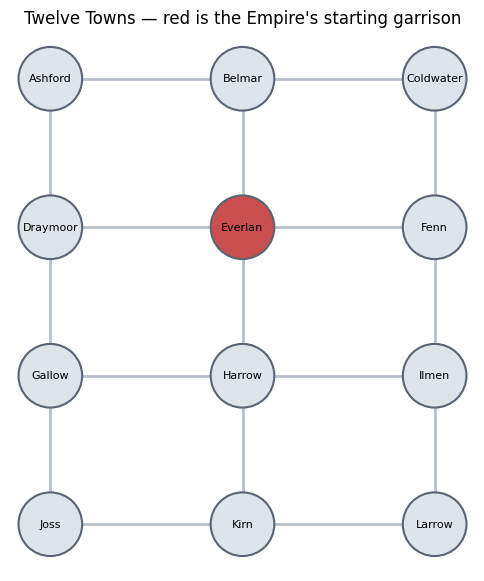

average degree 2.83, diameter 5
hops from the Empire start: {'everlan': 0, 'belmar': 1, 'draymoor': 1, 'fenn': 1, 'harrow': 1, 'ashford': 2, 'coldwater': 2, 'gallow': 2, 'ilmen': 2, 'kirn': 2, 'joss': 3, 'larrow': 3}


In [2]:
def plot_map(game_map, highlight=None, ax=None):
    G = nx.Graph()
    for t in game_map.towns:
        G.add_node(t.id)
    G.add_edges_from(game_map.edges)
    pos = {t.id: (t.x, -t.y) for t in game_map.towns}
    labels = {t.id: t.label for t in game_map.towns}
    colors = ["#c94f4f" if highlight and n in highlight else "#dfe3ea"
              for n in G.nodes]

    ax = ax or plt.gca()
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#b9c0cc", width=2)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors,
                           edgecolors="#5a6473", node_size=2100, linewidths=1.5)
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=8)
    ax.set_axis_off()
    return ax

fig, ax = plt.subplots(figsize=(6, 7))
plot_map(scenario.map, highlight=set(scenario.empire_start), ax=ax)
ax.set_title("Twelve Towns — red is the Empire's starting garrison")
plt.show()

print(f"average degree {scenario.map.average_degree:.2f}, diameter {scenario.map.diameter}")
print("hops from the Empire start:",
      dict(sorted(scenario.map.distances_from("everlan").items(), key=lambda kv: kv[1])))

## 2. Playing by hand

`Table` lets you drive a game yourself. Pass a bot for either side to have it play
automatically, or `None` to play that side too.

The board renders from the perspective of whoever is to move, so the hidden information
stays hidden — the Empire sees pile heights and whatever it has peeked at, the Insurgency
sees everything it placed.

In [3]:
t = Table("baseline", seed=7, empire=HeuristicEmpire())
t.map()

Ashford  0/0 ---Belmar   0/0 ---Coldwate 0/0
     |               |               |
Draymoor 0/0 ---Everlan  0/3 ---Fenn     0/0
     |               |               |
Gallow   0/0 ---Harrow   0/0 ---Ilmen    0/0
     |               |               |
Joss     0/0 ---Kirn     0/0 ---Larrow   0/0

cells show  name  pile/troops  (# = resolved)


In [4]:
t.show()
t.hand()

Round 1 — insurgency to move
Empire 0  ·  Insurgency 0    deck 55  hand 5

TOWN         PILE  TROOPS   INTEL                   STATUS
----------------------------------------------------------
Ashford         0       ·                           
Belmar          0       ·                           
Coldwater       0       ·                           
Draymoor        0       ·                           
Everlan         0       3                           
Fenn            0       ·                           
Gallow          0       ·                           
Harrow          0       ·                           
Ilmen           0       ·                           
Joss            0       ·                           
Kirn            0       ·                           
Larrow          0       ·                           

HAND: 4 influence, 1 dummy

PENDING THIS TURN:
  (5 cards still to place)
  [0] influence 
  [1] influence 
  [2] influence 
  [3] dummy     
  [4] influence 


Place the whole hand — the rules require it — and end the turn. The bot Empire then
replies automatically.

In [5]:
# The hand is random, so read its composition rather than assuming it.
influence = sum(1 for card in t.state.hand if card.influence > 0)
dummies = len(t.state.hand) - influence

t.place("everlan", influence=influence)  # real influence where the garrison sits
t.place("harrow", dummy=dummies)         # noise next door, to draw troops off
t.show()                                 # note the PENDING block before committing

Round 1 — insurgency to move
Empire 0  ·  Insurgency 0    deck 55  hand 5

TOWN         PILE  TROOPS   INTEL                   STATUS
----------------------------------------------------------
Ashford         0       ·                           
Belmar          0       ·                           
Coldwater       0       ·                           
Draymoor        0       ·                           
Everlan         0       3                           
Fenn            0       ·                           
Gallow          0       ·                           
Harrow          0       ·                           
Ilmen           0       ·                           
Joss            0       ·                           
Kirn            0       ·                           
Larrow          0       ·                           

HAND: 4 influence, 1 dummy

PENDING THIS TURN:
  place 4 influence + 0 dummy -> Everlan
  place 0 influence + 1 dummy -> Harrow


In [6]:
t.end_turn()

Round 2 — insurgency to move
Empire 4  ·  Insurgency 0    deck 50  hand 5

TOWN         PILE  TROOPS   INTEL                   STATUS
----------------------------------------------------------
Ashford         0       ·                           
Belmar          0       ·                           
Coldwater       0       ·                           
Draymoor        0       ·                           
Everlan         4  · (+4)                           resolved · empire · inf 4 v str 12
Fenn            0       ·                           
Gallow          0       ·                           
Harrow          1       ·   influence 0 of 1        
Ilmen           0       ·                           
Joss            0       ·                           
Kirn            0       ·                           
Larrow          0       ·                           

HAND: 3 influence, 2 dummy

PENDING THIS TURN:
  (5 cards still to place)


Now look at the same position from the other side of the table. This is the whole game in
one screen: the Empire sees a pile of 3 and knows only what its stationary troops read.

In [7]:
t.show(view=Side.EMPIRE)

Round 2 — insurgency to move
Empire 4  ·  Insurgency 0    deck 50  hand 5

TOWN         PILE  TROOPS   INTEL                   STATUS
----------------------------------------------------------
Ashford         0       ·                           
Belmar          0       ·                           
Coldwater       0       ·                           
Draymoor        0       ·                           
Everlan         4  · (+4)                           resolved · empire · inf 4 v str 12
Fenn            0       ·                           
Gallow          0       ·                           
Harrow          1       ·   nothing seen            
Ilmen           0       ·                           
Joss            0       ·                           
Kirn            0       ·                           
Larrow          0       ·                           

PENDING THIS TURN:
  (5 cards still to place)


You can keep going with `t.place(...)`, `t.resolve("everlan")`, `t.end_turn()`.
To play the Empire instead, use `t.generate(...)`, `t.move(src, dst, n)`, `t.resolve(...)`.
`t.reset_turn()` discards anything staged, and `t.log()` shows what has happened.

Pass no bots at all to play both sides yourself.

In [8]:
solo = Table("baseline", seed=11)        # no bots: you play both sides
solo.place("harrow", cards=len(solo.state.hand))   # dump the whole hand in one town
solo.end_turn(then_autoplay=False)       # now the Empire's turn, and yours to play

solo.generate("everlan")
solo.move("everlan", "harrow", 2)
solo.end_turn(then_autoplay=False)
solo.log()

Round 1 — empire to move
Empire 0  ·  Insurgency 0    deck 55  hand 0

TOWN         PILE  TROOPS   INTEL                   STATUS
----------------------------------------------------------
Ashford         0       ·                           
Belmar          0       ·                           
Coldwater       0       ·                           
Draymoor        0       ·                           
Everlan         0       3                           
Fenn            0       ·                           
Gallow          0       ·                           
Harrow          5       ·   nothing seen            
Ilmen           0       ·                           
Joss            0       ·                           
Kirn            0       ·                           
Larrow          0       ·                           
Round 2 — insurgency to move
Empire 0  ·  Insurgency 0    deck 50  hand 5

TOWN         PILE  TROOPS   INTEL                   STATUS
-----------------------------------------

## 3. Watching a whole game

Two heuristic bots, with the running log. This is the fastest way to sanity-check that
the rules produce something game-shaped rather than a degenerate loop.

In [9]:
rng = random.Random(4)
final = play_game(scenario, HeuristicEmpire(rng), HeuristicInsurgency(rng), rng)
for line in final.log:
    print(line)
print()
print("final:", {k.value: v for k, v in final.scores.items()}, "->", winner(final).value)

R1: Insurgency places 4->Everlan, 1->Draymoor
R1: Empire raises 1 at Everlan
R1: Everlan resolved (empire) — influence 4 vs strength 12 — empire takes it, scoring 4
R2: Insurgency places 4->Draymoor, 1->Fenn
R2: Empire raises 1 at Everlan
R3: Insurgency places 3->Fenn, 1->Ashford, 1->Belmar
R3: Empire raises 1 at Everlan
R3: Empire moves 1 Everlan->Draymoor
R3: Draymoor resolved (empire) — influence 4 vs strength 3 — insurgency takes it, scoring 3
R4: Insurgency places 3->Ashford, 1->Joss, 1->Gallow
R4: Empire raises 1 at Draymoor
R4: Empire moves 1 Everlan->Fenn
R5: Insurgency places 2->Fenn, 3->Ilmen
R5: Fenn resolved (insurgency) — influence 5 vs strength 3 — insurgency takes it, scoring 3
R5: Empire raises 1 at Draymoor
R5: Empire moves 1 Draymoor->Ashford
R6: Insurgency places 3->Ashford, 2->Belmar
R6: Ashford resolved (insurgency) — influence 5 vs strength 3 — insurgency takes it, scoring 3
R6: Empire raises 1 at Ashford
R6: Empire moves 1 Draymoor->Gallow
R7: Insurgency places 4

## 4. Is the baseline balanced?

No. Badly not.

In [10]:
def win_rates(games=300, bots="heuristic", **overrides):
    s = load_scenario("baseline", **overrides)
    rs = run_many(s, games, bots)
    n = len(rs)
    return {
        "empire": sum(1 for r in rs if r.winner == "empire") / n,
        "insurgency": sum(1 for r in rs if r.winner == "insurgency") / n,
        "draw": sum(1 for r in rs if r.winner == "draw") / n,
        "empire_score": statistics.mean(r.empire_score for r in rs),
        "insurgency_score": statistics.mean(r.insurgency_score for r in rs),
        "scenario": s,
    }

base = win_rates()
print(f"Empire     {base['empire']:.1%}")
print(f"Insurgency {base['insurgency']:.1%}")
print(f"draws      {base['draw']:.1%}")
print()
print(f"mean scores — Empire {base['empire_score']:.1f}, "
      f"Insurgency {base['insurgency_score']:.1f}")

Empire     83.3%
Insurgency 14.3%
draws      2.3%

mean scores — Empire 12.1, Insurgency 6.9


### The engagement numbers say why

Capture-only scoring means points only exist where someone *loses* a committed force.
So the useful diagnostic is not the score, it's **how much of each side's total budget ever
changed hands.** If those numbers are near zero, the game is mostly walkovers.

In [11]:
s = base["scenario"]
print(f"of all {s.total_strength} Empire strength, "
      f"{base['insurgency_score'] / s.total_strength:.1%} was overcome and scored")
print(f"of all {s.total_influence} Insurgency influence, "
      f"{base['empire_score'] / s.total_influence:.1%} was captured and scored")

of all 45 Empire strength, 15.4% was overcome and scored
of all 30 Insurgency influence, 40.2% was captured and scored


The Empire loses about 15% of its force to scoring fights; the Insurgency loses 40% of
its influence. The Empire is simply refusing bad fights and winning good ones.

## 5. The design doc's balance heuristic is wrong

The doc reasons about an **Empire premium** — total Empire strength divided by total
Insurgency influence — and suggests tuning until it approaches 1.0. That turns out to be
a poor predictor. Here are four configurations with premiums from 0.87 to 1.5:

In [12]:
trials = {
    "baseline (50% influence)": {},
    "troop strength 2": dict(unit=Unit("infantry", "Infantry", 2, 1, 1)),
    "strength 2, start 1 troop": dict(unit=Unit("infantry", "Infantry", 2, 1, 1),
                                      empire_start={"everlan": 1}),
    "deck 40 influence / 20 dummy": dict(deck={"influence": 40, "dummy": 20}),
}

print(f"{'configuration':<30}{'premium':>9}{'empire':>9}{'insurgency':>12}")
print("-" * 60)
for label, ov in trials.items():
    r = win_rates(200, **ov)
    print(f"{label:<30}{r['scenario'].empire_premium:>9.2f}"
          f"{r['empire']:>9.1%}{r['insurgency']:>12.1%}")

configuration                   premium   empire  insurgency
------------------------------------------------------------


baseline (50% influence)           1.50    82.5%       15.0%


troop strength 2                   1.00    82.0%       15.5%


strength 2, start 1 troop          0.87    69.5%       26.5%


deck 40 influence / 20 dummy       1.12    27.5%       66.0%


Dropping troop strength to 2 brings the premium to exactly 1.00 and moves the win rate
**almost not at all**. Changing the deck composition moves the premium far less and flips
the game completely.

The reason is that capture-only scoring makes troop strength self-cancelling: weaker troops
mean the Empire wins fewer fights, but also that each fight the Insurgency wins is worth
fewer points. The two effects very nearly cancel.

What actually binds is **influence density** — how much *real* influence the Insurgency can
concentrate in one place. With a 50/50 deck and mandatory placement, half of everything it
does is noise it is forced to make.

## 6. Deck composition is the real knob

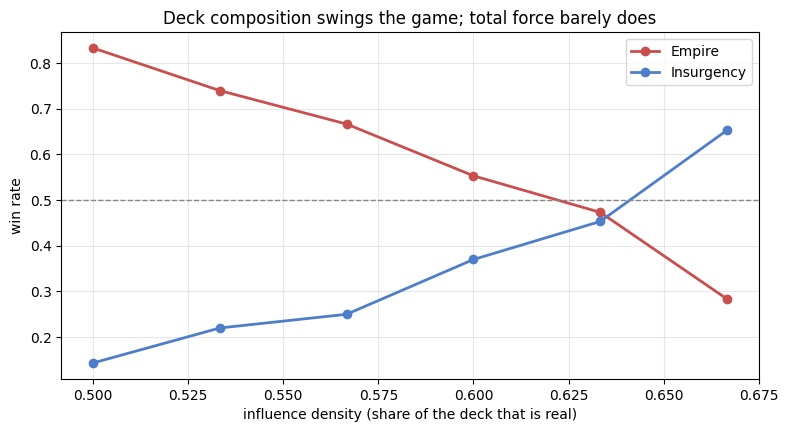

deck 30/30  density 50%  premium 1.50   empire 83.3%  insurgency 14.3%
deck 32/28  density 53%  premium 1.41   empire 74.0%  insurgency 22.0%
deck 34/26  density 57%  premium 1.32   empire 66.7%  insurgency 25.0%
deck 36/24  density 60%  premium 1.25   empire 55.3%  insurgency 37.0%
deck 38/22  density 63%  premium 1.18   empire 47.3%  insurgency 45.3%
deck 40/20  density 67%  premium 1.12   empire 28.3%  insurgency 65.3%


In [13]:
densities = [30, 32, 34, 36, 38, 40]
rows = []
for inf in densities:
    r = win_rates(300, deck={"influence": inf, "dummy": 60 - inf})
    rows.append((inf, r["empire"], r["insurgency"], r["scenario"].empire_premium))

fig, ax = plt.subplots()
ax.plot([r[0] / 60 for r in rows], [r[1] for r in rows], "o-",
        color="#c94f4f", label="Empire", linewidth=2)
ax.plot([r[0] / 60 for r in rows], [r[2] for r in rows], "o-",
        color="#4f7ec9", label="Insurgency", linewidth=2)
ax.axhline(0.5, color="#888", linestyle="--", linewidth=1)
ax.set_xlabel("influence density (share of the deck that is real)")
ax.set_ylabel("win rate")
ax.set_title("Deck composition swings the game; total force barely does")
ax.legend()
plt.show()

for inf, e, i, prem in rows:
    print(f"deck {inf}/{60-inf}  density {inf/60:.0%}  premium {prem:.2f}   "
          f"empire {e:.1%}  insurgency {i:.1%}")

Balance lands near **38 influence / 22 dummy** — about 63% density, not 50%. That is the
single most useful number in this notebook, and it is a long way from the doc's starting
guess.

## 7. Is the peek mechanic doing anything?

Peeking is the game's signature — the Empire's only way to pierce the fog. So it should
matter a great deal whether troops can see or not. Compare a normal Empire against one
that is completely blind:

In [14]:
for label, unit in [("peek 1 (normal)", Unit("infantry", "Infantry", 3, 1, 1)),
                    ("peek 0 (blind)",  Unit("infantry", "Infantry", 3, 1, 0)),
                    ("peek 3 (all-seeing)", Unit("infantry", "Infantry", 3, 1, 3))]:
    r = win_rates(300, unit=unit)
    print(f"{label:<22} empire {r['empire']:.1%}   insurgency {r['insurgency']:.1%}")

peek 1 (normal)        empire 83.3%   insurgency 14.3%


peek 0 (blind)         empire 82.3%   insurgency 15.3%


peek 3 (all-seeing)    empire 83.0%   insurgency 14.7%


**A blind Empire plays about as well as a sighted one.** The mechanic the whole design
rests on is currently close to inert.

Two possible readings, and they need different fixes:

- *The bots do not exploit information.* `HeuristicEmpire` uses its belief only to pick a
  march target and a resolve threshold. A player who actually used peeks to distinguish a
  bluff from a real stack would get far more out of them. This is the likelier explanation
  and it is a bot problem, not a design problem.
- *Peek 1 is too slow to matter.* One card per troop per turn against a pile growing by
  several cards a turn means the Empire never catches up.

Note that peek 3 does not help much either, which mildly favours the first reading — more
information does not help a bot that barely uses information.

Either way this is the thing to investigate before writing any PHP, because if peeking
genuinely does not matter, the game is much less interesting than the design intends.

## 8. Does board-shrinking dominate? (Decision 3)

The design doc flags a risk: because resolved towns become permanent generation anchors
*and* shrink the board, the Empire might profit from resolving towns cheaply just to
freeze them, even scoring nothing. `HeuristicEmpire(shrink=True)` does exactly that.

In [15]:
balanced = dict(deck={"influence": 38, "dummy": 22})

def duel(empire_factory, insurgency_factory, games=300, **overrides):
    s = load_scenario("baseline", **overrides)
    tally = {"empire": 0, "insurgency": 0, "draw": 0}
    for seed in range(games):
        rng = random.Random(seed)
        st = play_game(s, empire_factory(rng), insurgency_factory(rng), rng)
        w = winner(st)
        tally["draw" if w is None else w.value] += 1
    return {k: v / games for k, v in tally.items()}

normal = duel(lambda r: HeuristicEmpire(r), lambda r: HeuristicInsurgency(r), **balanced)
shrink = duel(lambda r: HeuristicEmpire(r, shrink=True),
              lambda r: HeuristicInsurgency(r), **balanced)

print(f"Empire playing normally    {normal['empire']:.1%}")
print(f"Empire playing to shrink   {shrink['empire']:.1%}")

Empire playing normally    47.3%
Empire playing to shrink   17.7%


**Board-shrinking loses badly** — it roughly thirds the Empire's win rate. Scoring nothing
in order to gain position is not worth it when points only come from capture.

That is good news for the design: the risk flagged against Decision 3 does not materialise,
so frozen troops can keep anchoring generation without opening a degenerate line.

## 9. Do dummies actually work as bait?

`HeuristicInsurgency(bait=True)` places dummies next to Empire troops to invite
over-commitment. `bait=False` scatters them at random.

In [16]:
on = duel(lambda r: HeuristicEmpire(r), lambda r: HeuristicInsurgency(r, bait=True), **balanced)
off = duel(lambda r: HeuristicEmpire(r), lambda r: HeuristicInsurgency(r, bait=False), **balanced)
print(f"dummies placed as bait     insurgency {on['insurgency']:.1%}")
print(f"dummies scattered randomly insurgency {off['insurgency']:.1%}")

dummies placed as bait     insurgency 45.3%
dummies scattered randomly insurgency 34.0%


Baiting is worth roughly 11 points of win rate. So *where* the noise goes matters, which
is the bluffing layer showing up in the numbers even with fairly crude bots. This is the
most encouraging result in the notebook.

## 10. Concentrate or spread? — unanswerable right now

The doc asks whether the Insurgency should concentrate influence or spread it. The
`spread` parameter should answer that, and it produces identical results for every value,
which is a red flag rather than a finding.

In [17]:
for spread in [1, 2, 3, 4]:
    r = duel(lambda rng: HeuristicEmpire(rng),
             lambda rng, s=spread: HeuristicInsurgency(rng, spread=s), **balanced)
    print(f"spread={spread}   insurgency {r['insurgency']:.1%}")

spread=1   insurgency 45.3%


spread=2   insurgency 45.3%


spread=3   insurgency 45.3%


spread=4   insurgency 45.3%


In [18]:
# Why: the Insurgency targets garrisoned towns, and there is almost never
# more than one to target.
s = load_scenario("baseline", **balanced)
counts = []
for seed in range(60):
    rng = random.Random(seed)
    st = new_game(s, rng)
    e, i = HeuristicEmpire(rng), HeuristicInsurgency(rng)
    while True:
        prepare_turn(st)
        if st.game_over:
            break
        if st.to_move is Side.INSURGENCY:
            counts.append(sum(1 for t in st.unresolved if t.troops > 0))
            apply_insurgency_turn(st, i.choose(st))
        else:
            apply_empire_turn(st, e.choose(st))

print(f"garrisoned unresolved towns when the Insurgency chooses:")
print(f"  mean {statistics.mean(counts):.2f}, max {max(counts)}, "
      f"more than one: {sum(1 for c in counts if c > 1) / len(counts):.1%}")

garrisoned unresolved towns when the Insurgency chooses:
  mean 0.59, max 2, more than one: 1.5%


The Empire moves as a single doomstack — it has troops in more than one contested town
about 1.5% of the time — so there is never a second target for the Insurgency to spread
*to*. That is an artifact of `HeuristicEmpire` moving every troop in a town together,
not a fact about the game.

**Fixing the Empire bot to split its force is the prerequisite for answering this
question.** It is also probably the prerequisite for question 7, since a doomstack has no
use for information about towns it is not standing in.

## Caveats — read this before quoting any number above

These bots are crude. They tell you about the **shape** of the game — whether the score
space is degenerate, whether a parameter does anything, whether a strategy is obviously
dominant. They do **not** tell you the game is balanced under skilled play.

Specifically:

- **A 50/50 win rate between weak bots is not balance.** It mostly says the game is noisy.
- **The Empire plays as one doomstack** and never splits, which distorts sections 7 and 10
  directly and probably softens everything else.
- **Neither side models its opponent's beliefs**, so the entire bluffing layer — the point
  of the design — is barely represented. The property from Decision 8, where the Insurgency
  can compute exactly what the Empire has seen, is not exploited by any bot here.
- **The Insurgency never holds back**, because the rules do not let it. But it also never
  reasons about *when* to resolve beyond a greedy threshold, and timing is most of the game.

The findings I would actually act on, in order of confidence:

1. **Deck composition is the strong knob and the balance point is near 63% influence, not
   50%.** Robust — it is a large effect across a clean monotonic sweep.
2. **Board-shrinking does not dominate.** Robust, and it clears Decision 3.
3. **Bait placement matters.** Encouraging, and it survives crude bots.
4. **The total-force "premium" heuristic in the design doc does not predict balance.**
   Robust, and the doc should be corrected.
5. **Peeking appears inert.** *Not* robust — most likely a bot limitation, and the single
   most important thing to re-test with a better Empire.